In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import rrrrrr

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

FICHIER = r"C:\Users\DELL\Desktop\L3 analyse de données\Mahine leanning\commerce\commerce\projet4_commerce_transactions.csv"

df = pd.read_csv(FICHIER)
df["date_facture"] = pd.to_datetime(df["date_facture"])

print("Dimensions :", df.shape)
display(df.head())


Dimensions : (11501, 10)


,no_facture,date_facture,code_produit,designation,categorie,quantite,prix_unitaire_fcfa,id_client,ville,mode_paiement
0,F106016,2024-01-01 09:16:00,P009,Bissap séché 250 g,Frais,1.0,720.0,10585.0,Rufisque,Orange Money
1,F106016,2024-01-01 09:16:00,P011,Eau de Javel 1 L,Hygiène,3.0,520.0,10585.0,Rufisque,Orange Money
2,F106016,2024-01-01 09:16:00,P007,Oignons 1 kg,Frais,1.0,620.0,10585.0,Rufisque,Orange Money
3,F102381,2024-01-01 10:32:00,P011,Eau de Javel 1 L,Hygiène,3.0,480.0,10077.0,Dakar,Wave
4,F102381,2024-01-01 10:32:00,P005,Café Touba 250 g,Épicerie,1.0,1140.0,10077.0,Dakar,Wave


Nombre de clients uniques : 630


,mois,chiffre_affaires_fcfa
0,2024-01,23683760.0
1,2024-02,21282890.0
2,2024-03,25353020.0
3,2024-04,21204330.0
4,2024-05,25114320.0
5,2024-06,22655380.0
6,2024-07,24122650.0
7,2024-08,22442850.0
8,2024-09,2154870.0


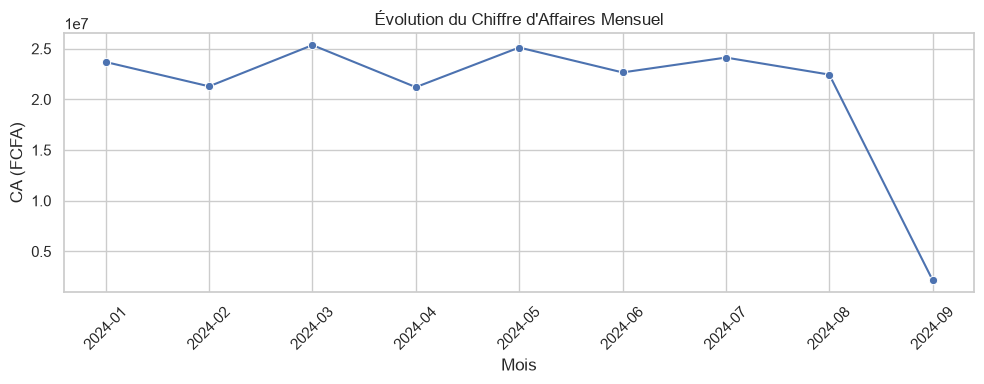

--- Top 10 Produits les plus vendus (en Quantité) ---


,code_produit,designation,quantite
0,P017,Écouteurs Bluetooth,1493.0
1,P009,Bissap séché 250 g,1483.0
2,P010,Savon de ménage (lot de 4),1466.0
3,P012,Couches bébé (x30),1457.0
4,P006,Thé vert chinois 100 g,1425.0
5,P011,Eau de Javel 1 L,1406.0
6,P019,Recharge crédit 5000 FCFA,1381.0
7,P002,Huile d'arachide 1 L,1378.0
8,P003,Sucre en morceaux 1 kg,1364.0
9,P005,Café Touba 250 g,1355.0


--- Top 10 Produits générant le plus de CA ---


,code_produit,designation,montant_ligne_fcfa
0,P016,Téléphone Android entrée de gamme,44614550.0
1,P014,Boubou brodé homme,33659770.0
2,P018,Ventilateur sur pied,19233080.0
3,P015,Chaussures en cuir,17159670.0
4,P017,Écouteurs Bluetooth,12851990.0
5,P020,Bouilloire électrique,12828760.0
6,P013,Pagne wax 6 yards,10996650.0
7,P012,Couches bébé (x30),8128540.0
8,P019,Recharge crédit 5000 FCFA,7021170.0
9,P001,Riz brisé parfumé 5 kg,6106960.0


In [20]:
# Chiffre d'affaires par mois, produits les plus vendus, nombre de clients.

nb_clients = df['id_client'].nunique()
print(f"Nombre de clients uniques : {nb_clients}")

# 2. Chiffre d'affaires par mois
df['montant_ligne_fcfa'] = df['quantite'] * df['prix_unitaire_fcfa']
ca_mensuel = df.groupby(df['date_facture'].dt.to_period('M'))['montant_ligne_fcfa'].sum().reset_index()
ca_mensuel.columns = ['mois', 'chiffre_affaires_fcfa']

display(ca_mensuel)

# Graphique du chiffre d'affaires mensuel
plt.figure(figsize=(10, 4))
sns.lineplot(data=ca_mensuel, x=ca_mensuel['mois'].astype(str), y='chiffre_affaires_fcfa', marker='o', color='b')
plt.title("Évolution du Chiffre d'Affaires Mensuel")
plt.xlabel("Mois")
plt.ylabel("CA (FCFA)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Top 10 des produits les plus vendus (en quantité et en CA)
top_quantite = df.groupby(['code_produit', 'designation'])['quantite'].sum().nlargest(10).reset_index()
top_ca = df.groupby(['code_produit', 'designation'])['montant_ligne_fcfa'].sum().nlargest(10).reset_index()

print("--- Top 10 Produits les plus vendus (en Quantité) ---")
display(top_quantite)

print("--- Top 10 Produits générant le plus de CA ---")
display(top_ca)



In [21]:
# Pour le RFM, on conserve uniquement les achats positifs, sans doublons, effectués par des clients identifiés.
clean = df.drop_duplicates().copy()
clean = clean.dropna(subset=['id_client'])
clean = clean[(clean['quantite'] > 0) & (~clean['no_facture'].str.startswith('A', na=False))].copy()
clean['id_client'] = clean['id_client'].astype(int)
clean['montant_ligne_fcfa'] = clean['quantite'] * clean['prix_unitaire_fcfa']
print('Lignes après nettoyage :', len(clean))


Lignes après nettoyage : 10652


In [34]:
# Construire les indicateurs RFM
#Pour chaque client : Récence (jours depuis le dernier achat), 
#Fréquence (nombre de commandes) et Montant (total dépensé).
#- Récence : jours depuis le dernier achat.
#- Fréquence : nombre de factures distinctes.
#- Montant : dépenses cumulées en FCFA
# 1. Date de référence : lendemain du dernier achat présent dans le dataset
date_reference = clean['date_facture'].max().normalize() + pd.Timedelta(days=1)

# 2. Calcul des 3 indicateurs RFM par client
rfm = clean.groupby('id_client').agg(
    recence_jours=('date_facture', lambda x: (date_reference - x.max().normalize()).days),
    frequence_commandes=('no_facture', 'nunique'),
    montant_total_fcfa=('montant_ligne_fcfa', 'sum')
).reset_index()

# 3. Affichage des statistiques descriptives
display(rfm.describe().round(2))


,id_client,recence_jours,frequence_commandes,montant_total_fcfa
count,630.00,630.00,630.00,630.00
mean,10367.38,63.07,5.55,286976.35
std,223.30,60.99,5.08,445932.24
min,10001.00,1.00,1.00,610.00
25%,10158.25,15.00,2.00,30075.00
50%,10370.50,41.00,4.00,117470.00
75%,10572.75,95.75,8.00,349295.00
max,10730.00,247.00,24.00,2976720.00


In [33]:
#La transformation logarithmique réduit l'influence des très gros acheteurs. 
#La standardisation donne le même poids aux trois indicateurs.
# 1. Transformation logarithmique (log1p évite log(0)) et standardisation
# 1. Liste des variables RFM à transformer
variables = ['recence_jours', 'frequence_commandes', 'montant_total_fcfa']

# 2. Transformation logarithmique (log1p permet de traiter l'asymétrie)
X_log = np.log1p(rfm[variables])

# 3. Standardisation (centrer-réduire pour donner le même poids aux variables)
scaler = StandardScaler()
X = scaler.fit_transform(X_log)

# 4. Conversion en DataFrame pour vérifier les moyennes (proches de 0) et écarts-types (proches de 1)
X_df = pd.DataFrame(X, columns=[f'{col}_scaled' for col in variables])
display(X_df.describe().round(2))

,recence_jours_scaled,frequence_commandes_scaled,montant_total_fcfa_scaled
count,630.00,630.00,630.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.56,-1.25,-3.05
25%,-0.74,-0.69,-0.71
50%,0.10,0.00,0.11
75%,0.83,0.80,0.76
max,1.65,2.20,2.05


,k,inertie,silhouette
0,2,840.344,0.466
1,3,656.303,0.335
2,4,510.151,0.354
3,5,429.237,0.310
4,6,382.512,0.277
5,7,347.548,0.282
6,8,311.863,0.286


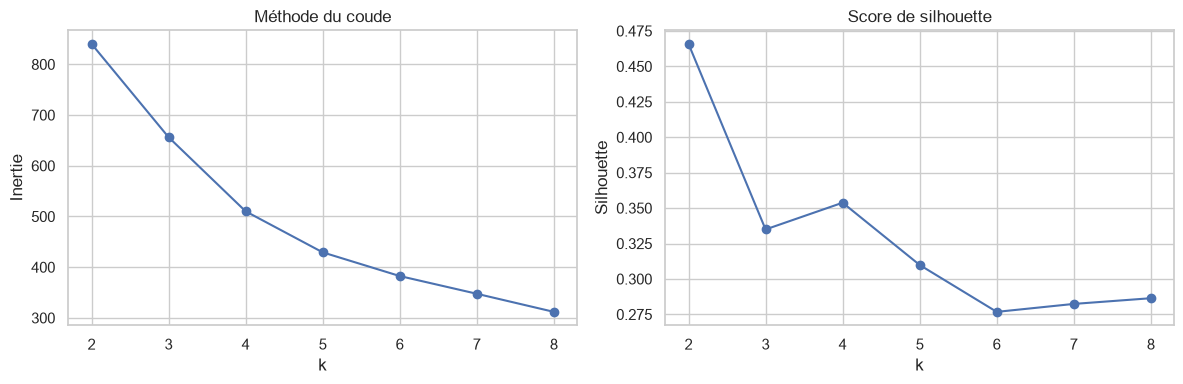

Nombre de segments retenu : 2


In [19]:
#Utiliser la méthode du coude et le score de silhouette.
# Évaluation du nombre optimal de clusters K (Méthode du Coude & Score de Silhouette)
#Le coude cherche une diminution qui ralentit.
#La silhouette mesure la séparation entre groupes : 
#plus elle est proche de 1, meilleure est la séparation.


import os
import warnings

# 1. Empêcher les fuites de mémoire (memory leak) sous Windows et masquer les avertissements
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings('ignore')

# 2. Évaluation du nombre optimal de clusters K (Méthode du Coude & Score de Silhouette)
diagnostic = []
for k in range(2, 9):
    modele = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = modele.fit_predict(X)
    diagnostic.append([k, modele.inertia_, silhouette_score(X, labels)])

# 3. Création du DataFrame récapitulatif
diagnostic = pd.DataFrame(diagnostic, columns=['k', 'inertie', 'silhouette'])
display(diagnostic.round(3))

# 4. Affichage des graphiques d'évaluation
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(diagnostic.k, diagnostic.inertie, marker='o')
ax[0].set(title='Méthode du coude', xlabel='k', ylabel='Inertie')

ax[1].plot(diagnostic.k, diagnostic.silhouette, marker='o')
ax[1].set(title='Score de silhouette', xlabel='k', ylabel='Silhouette')

plt.tight_layout()
plt.show()

# 5. Sélection automatique du K optimal selon le score de silhouette
k_optimal = int(diagnostic.loc[diagnostic.silhouette.idxmax(), 'k'])
print('Nombre de segments retenu :', k_optimal)

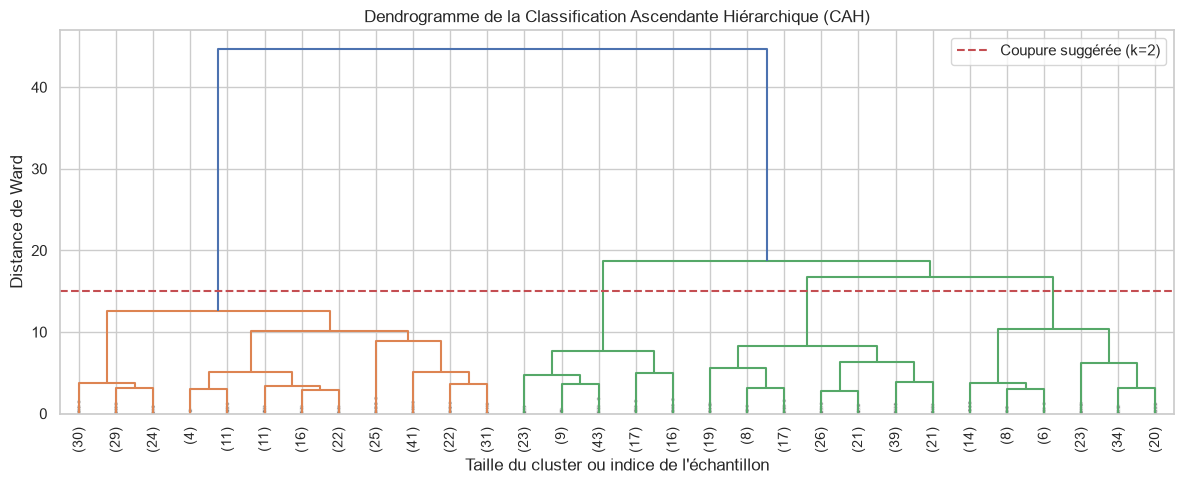

--- Matrice de croisement K-Means vs CAH ---


CAH,0,1
K-Means,,
0,326,0
1,38,266


Score de Silhouette K-Means : 0.466
Score de Silhouette CAH     : 0.444


In [24]:
# Modélisation	Appliquer K-means, puis comparer éventuellement avec un clustering hiérarchique.
# 1. Entraînement du modèle K-Means final avec le nombre de clusters optimal
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import confusion_matrix

# 1. Génération et affichage du Dendrogramme (Méthode de Ward)
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title("Dendrogramme de la Classification Ascendante Hiérarchique (CAH)")
plt.xlabel("Taille du cluster ou indice de l'échantillon")
plt.ylabel("Distance de Ward")
plt.axhline(y=15, color='r', linestyle='--', label='Coupure suggérée (k=2)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Entraînement de la CAH avec k_optimal
cah = AgglomerativeClustering(n_clusters=k_optimal, linkage='ward')
rfm['cluster_cah'] = cah.fit_predict(X)

# 3. Comparaison K-Means vs CAH (Matrice de confusion / Croisement des clusters)
matrice_croisee = pd.crosstab(rfm['cluster'], rfm['cluster_cah'], 
                              colnames=['CAH'], rownames=['K-Means'])

print("--- Matrice de croisement K-Means vs CAH ---")
display(matrice_croisee)

# 4. Score de Silhouette de la CAH pour comparaison
score_cah = silhouette_score(X, rfm['cluster_cah'])
score_kmeans = silhouette_score(X, rfm['cluster'])

print(f"Score de Silhouette K-Means : {score_kmeans:.3f}")
print(f"Score de Silhouette CAH     : {score_cah:.3f}")

Variance expliquée par les deux axes : 93.4 %


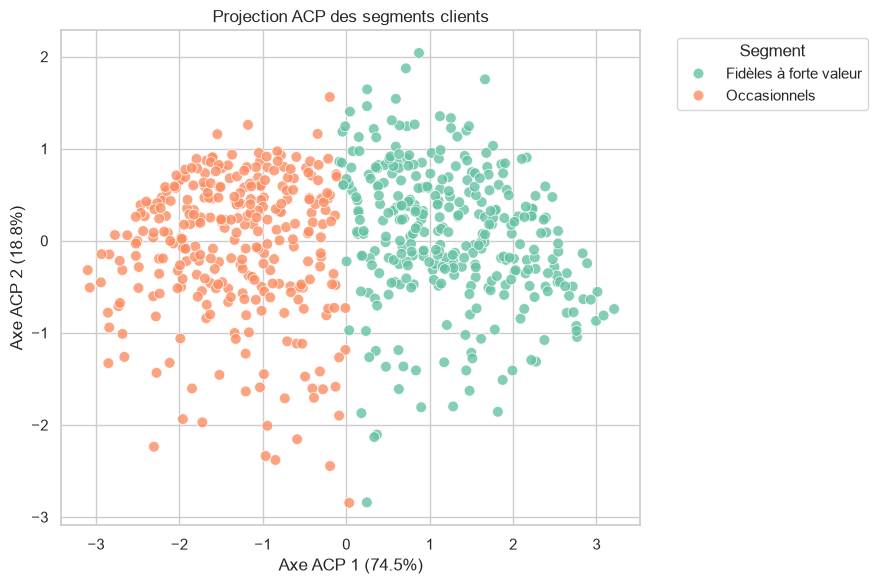

In [25]:
#Décrire chaque segment (clients fidèles, clients à forte valeur,
#clients à risque de départ, nouveaux clients) et lui donner un nom métier


In [30]:
## Proposer une action par segment : programme de fidélité, relance par SMS, offre de réactivation.

# 1. Définition de la table des stratégies marketing par segment (adaptée aux 2 segments retenus)
strategies = pd.DataFrame({
 'segment':['Fidèles à forte valeur','À développer ou réactiver','Occasionnels'],
 'action':['Programme VIP et ventes croisées','Relance SMS/WhatsApp avec offre limitée','Promotions ciblées par catégorie'],
 'objectif':['Préserver la valeur','Augmenter la fréquence ou réactiver','Déclencher un nouvel achat']
})
display(strategies)
rfm.to_csv('clients_segmentes.csv', index=False, encoding='utf-8-sig')
diagnostic.to_csv('diagnostic_k.csv', index=False, encoding='utf-8-sig')




,segment,action,objectif
0,Fidèles à forte valeur,Programme VIP et ventes croisées,Préserver la valeur
1,À développer ou réactiver,Relance SMS/WhatsApp avec offre limitée,Augmenter la fréquence ou réactiver
2,Occasionnels,Promotions ciblées par catégorie,Déclencher un nouvel achat


In [31]:
#synthèse de métier globale et la répartition par segment
# Synthèse finale des 2 segments
synthese = rfm.groupby('segment').agg(
    nombre_clients=('id_client', 'count'),
    recence_moyenne_jours=('recence_jours', 'mean'),
    frequence_moyenne=('frequence_commandes', 'mean'),
    panier_moyen_fcfa=('montant_total_fcfa', lambda x: (x / rfm.loc[x.index, 'frequence_commandes']).mean()),
    ca_total_fcfa=('montant_total_fcfa', 'sum')
).reset_index()

# Calcul de la part du CA total
total_ca = synthese['ca_total_fcfa'].sum()
synthese['part_ca_%'] = (synthese['ca_total_fcfa'] / total_ca * 100).round(1)

display(synthese.round(1))

,segment,nombre_clients,recence_moyenne_jours,frequence_moyenne,panier_moyen_fcfa,ca_total_fcfa,part_ca_%
0,Fidèles à forte valeur,326,27.4,9.1,69704.9,166707080.0,92.2
1,Occasionnels,304,101.3,1.8,25953.3,14088020.0,7.8


In [ ]:
#Cette ligne sert à transformer vos données de ventes en format binaire (0 ou 1) 
#pour préparer l'algorithme de recommandation (Apriori)
!pip install mlxtend
!pip install prophet
basket_binary = (basket > 0).astype(int)

In [49]:
#Système de recommandation de produits ou prévision des ventes
#Système de Recommandation de Produits
import pandas as pd
import warnings
from mlxtend.frequent_patterns import apriori, association_rules

# Masquer les messages d'avertissement
warnings.filterwarnings('ignore')

# 1. Pivot de la base : Facture x Produits
basket = (df.groupby(['no_facture', 'designation'])['quantite']
          .sum().unstack().reset_index().fillna(0)
          .set_index('no_facture'))

# Conversion en booléen
basket_binary = basket > 0

# 2. Application de l'algorithme Apriori
frequent_itemsets = apriori(basket_binary, min_support=0.01, use_colnames=True)

# 3. Génération des règles d'association
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
rules = rules.sort_values(by='lift', ascending=False)

# 4. Formate le tableau pour une lecture claire
rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))

# Affichage sous forme de dataframe propre
display(rules_display.head())

,antecedents,consequents,support,confidence,lift
0,Boubou brodé homme,Pagne wax 6 yards,0.012002,0.153094,2.125950
1,Pagne wax 6 yards,Boubou brodé homme,0.012002,0.166667,2.125950
8,Téléphone Android entrée de gamme,Pagne wax 6 yards,0.011236,0.144262,2.003302
9,Pagne wax 6 yards,Téléphone Android entrée de gamme,0.011236,0.156028,2.003302
6,Pagne wax 6 yards,Chaussures en cuir,0.010725,0.148936,1.887489


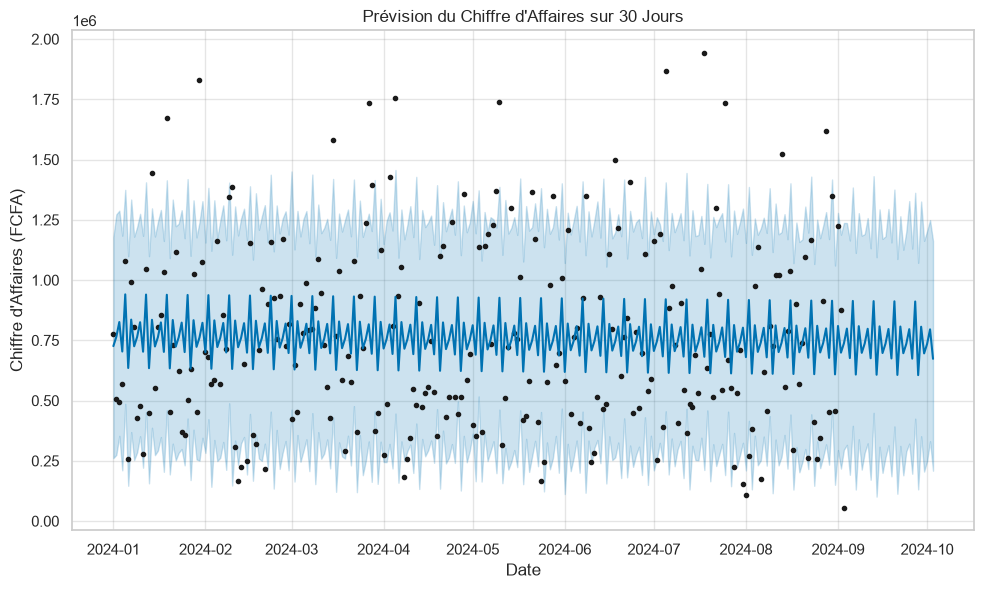

,Date,CA Prédit (FCFA),Estimation Basse,Estimation Haute
247,2024-09-04,798690.289099,316230.924849,1.236794e+06
248,2024-09-05,676432.259040,192195.543289,1.164273e+06
249,2024-09-06,913502.320549,395291.646306,1.384290e+06
250,2024-09-07,608057.729842,130994.515169,1.112565e+06
251,2024-09-08,808808.877984,339465.470142,1.277807e+06
252,2024-09-09,698108.361479,213619.931812,1.184410e+06
253,2024-09-10,736917.104339,283716.425164,1.190716e+06
254,2024-09-11,797914.461930,322616.655462,1.257371e+06
255,2024-09-12,675656.431872,171588.678715,1.131952e+06
256,2024-09-13,912726.493380,449139.895576,1.431201e+06


In [52]:
#Prévision des Ventes (Prophet)
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import logging

# Masquer les journaux d'information de Prophet
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# 1. Préparation des données (Ventes quotidiennes)
df['date_facture'] = pd.to_datetime(df['date_facture'])
df['montant_total'] = df['quantite'] * df['prix_unitaire_fcfa']

daily_sales = df.groupby(df['date_facture'].dt.date)['montant_total'].sum().reset_index()
daily_sales.columns = ['ds', 'y']

# 2. Entraînement du modèle
model = Prophet(yearly_seasonality=False, weekly_seasonality=True)
model.fit(daily_sales)

# 3. Prévision sur les 30 prochains jours
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# 4. Affichage du graphique
fig = model.plot(forecast)
plt.title("Prévision du Chiffre d'Affaires sur 30 Jours")
plt.xlabel("Date")
plt.ylabel("Chiffre d'Affaires (FCFA)")
plt.show()

# 5. Affichage du tableau des prévisions chiffrées pour les 30 prochains jours
previsions_30j = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)
previsions_30j.columns = ['Date', 'CA Prédit (FCFA)', 'Estimation Basse', 'Estimation Haute']

display(previsions_30j)